<a href="https://colab.research.google.com/github/TcHaOcHeK/ML/blob/4/LR4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Задание 4
Многомерная регрессия
Цель работы: изучение принципов решения задачи многомерной регрессии с использованием методов машинного обучения.

Выполним анализ набора данных octan.
При исследовании производственного процесса на нефтеперерабатывающем за-воде, октановое число конкретного бензина было измерено как функция от трех видов сырья, и переменной, которая характеризовала условия производства.

Смысл задачи - прогнозировать получаемое октановое число бенизина на производстве.

Набор данных включает следующие атрибуты:
* I – индекс
* A0 – 1
* A1 – количество материала 1
* A2 – количество материала 2
* A3 – количество материала 3
* A4 – оценка производственных условий
* B – октановое число

## Импортируем библиотеки

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt


## Загружем данные и получем информацию о датасете

In [54]:
data = pd.read_csv("octan.csv")
data.head()

,Number,One,Material_1,Material_2,Material_3,Condition,Octane
0,1,1,55.33,1.72,54,1.66219,92.19
1,2,1,59.13,1.20,53,1.58399,92.74
2,3,1,57.39,1.42,55,1.61731,91.88
3,4,1,56.43,1.78,55,1.66228,92.80
4,5,1,55.98,1.58,54,1.63195,92.56


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Number      82 non-null     int64  
 1   One         82 non-null     int64  
 2   Material_1  82 non-null     float64
 3   Material_2  82 non-null     float64
 4   Material_3  82 non-null     int64  
 5   Condition   82 non-null     float64
 6   Octane      82 non-null     float64
dtypes: float64(4), int64(3)
memory usage: 4.6 KB


## Проверяем на пропущенные значения

In [56]:
print(data.isnull().sum())

Number        0
One           0
Material_1    0
Material_2    0
Material_3    0
Condition     0
Octane        0
dtype: int64


В датасете нет категориальных значений

In [57]:
for col in data.columns:
    print(f"Column '{col}': {data[col].nunique()} unique values")

Column 'Number': 82 unique values
Column 'One': 1 unique values
Column 'Material_1': 82 unique values
Column 'Material_2': 59 unique values
Column 'Material_3': 20 unique values
Column 'Condition': 82 unique values
Column 'Octane': 72 unique values


В поле "ONE" задато одно значение на весь датафрейм, для проведения регресии, можно опустить данный  показатель

In [58]:
data = data.drop('One', axis=1, errors='ignore')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Number      82 non-null     int64  
 1   Material_1  82 non-null     float64
 2   Material_2  82 non-null     float64
 3   Material_3  82 non-null     int64  
 4   Condition   82 non-null     float64
 5   Octane      82 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 4.0 KB


## Разделяем данные на признаки и целевую переменную

In [59]:
y = data['Octane']
X = data.drop('Octane', axis = 1)

X.head()

,Number,Material_1,Material_2,Material_3,Condition
0,1,55.33,1.72,54,1.66219
1,2,59.13,1.20,53,1.58399
2,3,57.39,1.42,55,1.61731
3,4,56.43,1.78,55,1.66228
4,5,55.98,1.58,54,1.63195


## Разделяем данные на обучающую и тестовую выборку
75% данных используется для обучения и 25% для тестирования.

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=0)

## Применяем операцию нормализации для численной устойчивости

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
scaler = StandardScaler()
scaler

StandardScaler()

## Масштабируем признаки обучающей выборки

In [62]:
X_train_scaled = scaler.fit_transform(X_train)

scaler.mean_, scaler.scale_

(array([40.68852459, 61.2247541 ,  1.33393443, 55.81967213,  1.61348918]),
 array([23.49575545,  9.29651823,  1.31411415,  4.95060254,  0.21291169]))

## Обучаем модель линейной регрессии

In [63]:
model = LinearRegression().fit(X_train_scaled, y_train)
model

LinearRegression()

# Делаем прогноз на основе данных тестирования

In [64]:
# преобразуем тестовые данные с использованием среднего и СКО, рассчитанных на обучающей выборке
# так тестовые данные не повляют на обучение модели, и мы избежим утечки данных
X_test_scaled = scaler.transform(X_test)

# сделаем прогноз на стандартизированных тестовых данных
y_pred = model.predict(X_test_scaled)

y_pred[:5]

array([91.10034378, 92.42717991, 90.85894604, 90.72606986, 92.49052459])

In [65]:
from sklearn.metrics import root_mean_squared_error

print('Root Mean Squared Error (RMSE):', root_mean_squared_error(y_test, y_pred))

Root Mean Squared Error (RMSE): 0.49541979048209234


In [66]:
from sklearn.metrics import r2_score
print('R2:', np.round(r2_score(y_test, y_pred), 2))

R2: 0.93


оценим R-квадрат

In [67]:
model.score(X_test_scaled, y_test)

0.9315426772624867

## Итоговое уравнение

In [68]:
print('Coefficents: ', model.coef_)

Coefficents:  [-0.17073797 -0.81405813 -0.12964784 -0.26402333  0.35595351]


In [69]:
print('Intercept: ', model.intercept_)

Intercept:  91.77590163934424


# Оценим влияние признаков на целевую переменную

Так как наш датасет не имеет выбросов и пропущенных значений и у нас нет категориальных значений, мы можем сразу приступить к оценке.

In [70]:
data.corr()

,Number,Material_1,Material_2,Material_3,Condition,Octane
Number,1.000000,0.044019,0.238200,-0.538967,0.247489,0.013758
Material_1,0.044019,1.000000,-0.589451,0.448733,-0.336917,-0.870159
Material_2,0.238200,-0.589451,1.000000,-0.298396,0.161196,0.392359
Material_3,-0.538967,0.448733,-0.298396,1.000000,-0.721748,-0.638490
Condition,0.247489,-0.336917,0.161196,-0.721748,1.000000,0.628730
Octane,0.013758,-0.870159,0.392359,-0.638490,0.628730,1.000000


# Визуализвция результатов регресии

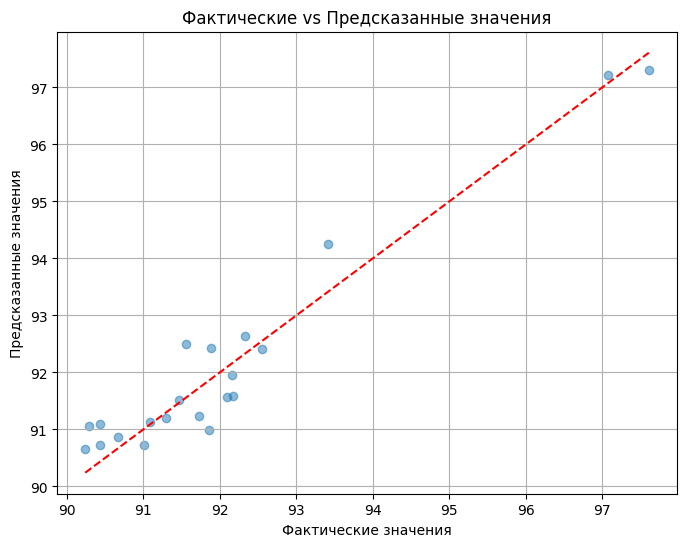

In [71]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Фактические vs Предсказанные значения")
plt.grid()
plt.show()

Видно, что на графике точки расположены вдоль прямой, что говорит о высоком качестве модели

Предсказанные значения близки к фактическим

# Остатки регрессии

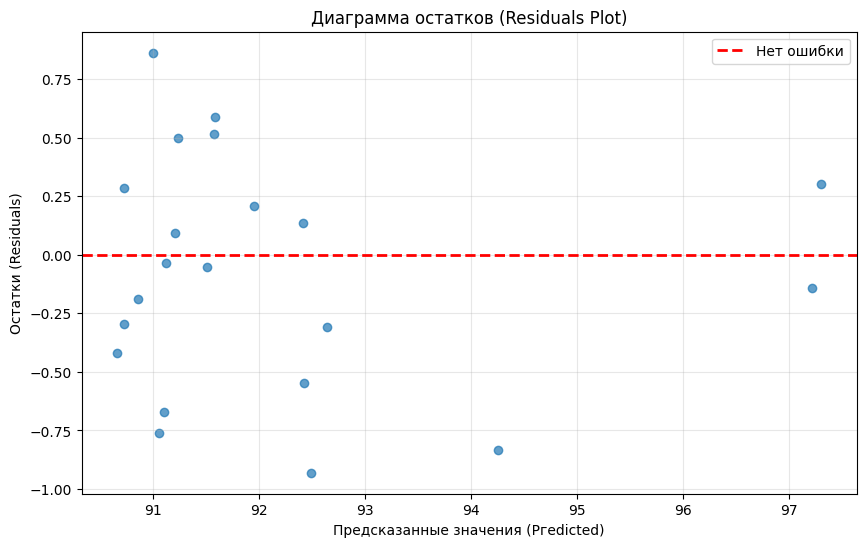

In [72]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter (y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Heт oшибки')
plt.xlabel('Предсказанные значения (Ргedicted)')
plt.ylabel('Oстатки (Residuals)')
plt.title('Диаграмма остатков (Residuals Plot)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Закономерности в распределении остатков регресии - не наблюдается